# Single-unit responses to social and non-social fixations

**Thesis chapter results — part 1.**

Neurons were recorded simultaneously from the basolateral amygdala (BLA) together
with one of three prefrontal regions — gyral anterior cingulate cortex (ACCg),
dorsomedial prefrontal cortex (dmPFC), or orbitofrontal cortex (OFC) — while two
macaques freely viewed one another. Every fixation falls into one of three
categories: **interactive face**, **non-interactive face**, or **object**.

The argument, in order:

| § | Claim |
|---|---|
| 2 | Individual neurons are selective for interactive face fixations. |
| 3 | Interactive face is the most frequently preferred category across the population. |
| 4 | But different subpopulations differentiate different fixation pairs — selectivity is not one thing. |
| 5 | Two metrics describe the firing-rate profile: **dominant-peak width** and **dominant-peak prominence**. |
| 6 | Selective neurons occupy a continuum in that space, not discrete types. |
| 7 | Dominant-peak width differs by fixation category (supplementary). |

Every figure is one row of four region panels, saved as an Illustrator-editable
PDF (embedded TrueType, no clipping masks) plus a 400 dpi PNG. All plotting lives
in `src/dal_monte_2022_analysis/ephys/plotting/`; this notebook orchestrates and
displays only.

## 1 · Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit as figs
from dal_monte_2022_analysis.ephys.plotting import thesis_single_unit_data as data
from dal_monte_2022_analysis.ephys.plotting import thesis_chapter_text as text
from dal_monte_2022_analysis.ephys.plotting import thesis_metric_space as space
from dal_monte_2022_analysis.ephys.plotting import thesis_trace_metrics as metrics
from dal_monte_2022_analysis.ephys.analysis.fixation_peakiness import (
    decompose_dominant_peak_prominence,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
PLOTTING_CFG_PATH = repo_root / "configs" / "plotting.yaml"
PSTH_CFG_PATH = repo_root / "configs" / "ephys_fixation_psth.yaml"

dataset_cfg = load_config(DATASET_CFG_PATH)
plotting_cfg = load_config(PLOTTING_CFG_PATH)
psth_cfg = load_config(PSTH_CFG_PATH)

style.apply_thesis_plot_style(plotting_cfg)
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

ANALYSIS_ROOT = data.resolve_psth_analysis_root(dataset_cfg)
FIGURE_SETTINGS = style.ThesisFigureSettings(output_dir=ANALYSIS_ROOT / "single_unit_thesis")
FIGURE_SETTINGS.output_dir.mkdir(parents=True, exist_ok=True)

FIGURE_MANIFEST: dict[str, dict[str, Path]] = {}

In [2]:
units = data.load_thesis_unit_table(ANALYSIS_ROOT)
pair_selectivity = data.load_pair_selectivity(ANALYSIS_ROOT)
condition_traces = data.load_condition_traces(ANALYSIS_ROOT)
trace_shape = data.load_trace_shape_table(ANALYSIS_ROOT, units)
trace_shape_all = data.load_trace_shape_table(ANALYSIS_ROOT, units, condition="all")
matched_cv, matched_cv_stats, cv_inflation = data.load_trial_matched_cv(ANALYSIS_ROOT)

unit_plot_settings = data.build_unit_plot_settings(
    DATASET_CFG_PATH, PLOTTING_CFG_PATH, psth_cfg
)
peakiness_settings = data.build_peakiness_settings(DATASET_CFG_PATH, psth_cfg)

print(f"{len(units)} units | {units['is_selective'].sum()} fixation-category-modulated")
print(f"{units['date'].nunique()} sessions | figures -> {FIGURE_SETTINGS.output_dir}")

1201 units | 574 fixation-category-modulated
42 sessions | figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/single_unit_thesis


## 2 · Neurons selective for interactive face fixations

Four example units, one per region. Each is significant on **both** interactive-face
contrasts (int vs non-int face, and int vs object) after FDR correction, and each
fires most for interactive face across the fixation window.

Rasters are subsampled to 70 trials per category so individual spikes stay visible;
the firing-rate traces use all trials (mean ± SEM, 10 ms bins, 20 ms Gaussian
smoothing). The three grey bars mark the analysis windows used in §4.

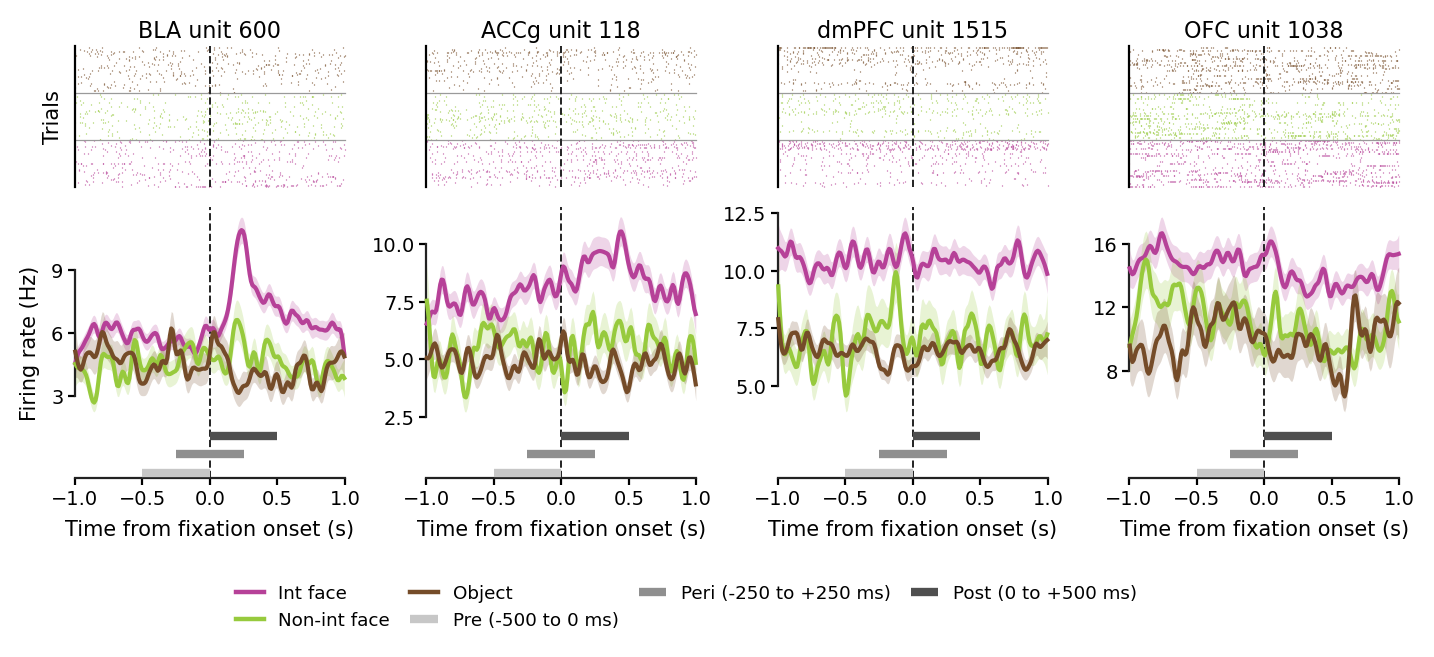

,region_label,uuid,date,mean_fr_face_interactive_hz,mean_fr_face_non_interactive_hz,mean_fr_object_hz,n_selective_pairs
0,BLA,600,2062018,6.80,4.92,4.40,2
1,ACCg,118,1172018,8.54,5.62,4.87,3
2,dmPFC,1515,2072018,10.49,7.23,6.46,2
3,OFC,1038,2062018,14.45,10.84,10.17,2


In [3]:
INT_FACE_EXAMPLES = {"bla": "600", "accg": "118", "dmpfc": "1515", "ofc": "1038"}

example_units = data.build_exemplar_table(
    units, {region: {"int_face": uuid} for region, uuid in INT_FACE_EXAMPLES.items()}
)
example_specs = data.build_example_unit_panel_specs(
    example_units,
    style="int_face",
    unit_settings=unit_plot_settings,
    peakiness_settings=peakiness_settings,
    condition_traces=condition_traces,
)
fig = figs.plot_example_unit_panel(example_specs, show_window_legend=True)
FIGURE_MANIFEST["fig01_interactive_face_examples"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig01_interactive_face_examples"
)
display(Image(data=style.figure_to_png_bytes(fig)))

window_means = pd.read_csv(
    ANALYSIS_ROOT / "fixation_psth_selectivity" / "condition_window_means.csv"
)
window_means = window_means.loc[window_means["window_name"] == "full_fix"]
display(
    example_units.merge(
        window_means.loc[
            :,
            ["unit_key", "mean_fr_face_interactive_hz", "mean_fr_face_non_interactive_hz",
             "mean_fr_object_hz"],
        ],
        on="unit_key",
        how="left",
    ).loc[
        :, ["region_label", "uuid", "date", "mean_fr_face_interactive_hz",
            "mean_fr_face_non_interactive_hz", "mean_fr_object_hz", "n_selective_pairs"]
    ].round(2)
)

## 3 · Interactive face is the preferred category across the population

A unit counts as **fixation-category-modulated** if its firing rate differs
significantly between at least one category pair in at least one of three 500 ms
windows (Welch's *t*-test on per-trial window means, FDR corrected across all
pair × window tests within the unit). For each such unit, the panel below asks
which category evoked the highest mean rate over the full −500 to +500 ms window.

Categories are compared **against each other** rather than against a 1/3 reference:
each unit has exactly one preferred category, so the three counts are one multinomial
over a fixed n, and what matters is whether more units prefer one category than
another. Two categories are compared by restricting to the units preferring either of
them and testing that split against 0.5 (exact binomial), FDR corrected across the
region × pair family. Only significant contrasts are marked. Bars carry Wilson 95%
intervals; the pies above show composition, which cannot carry uncertainty and is
therefore secondary.

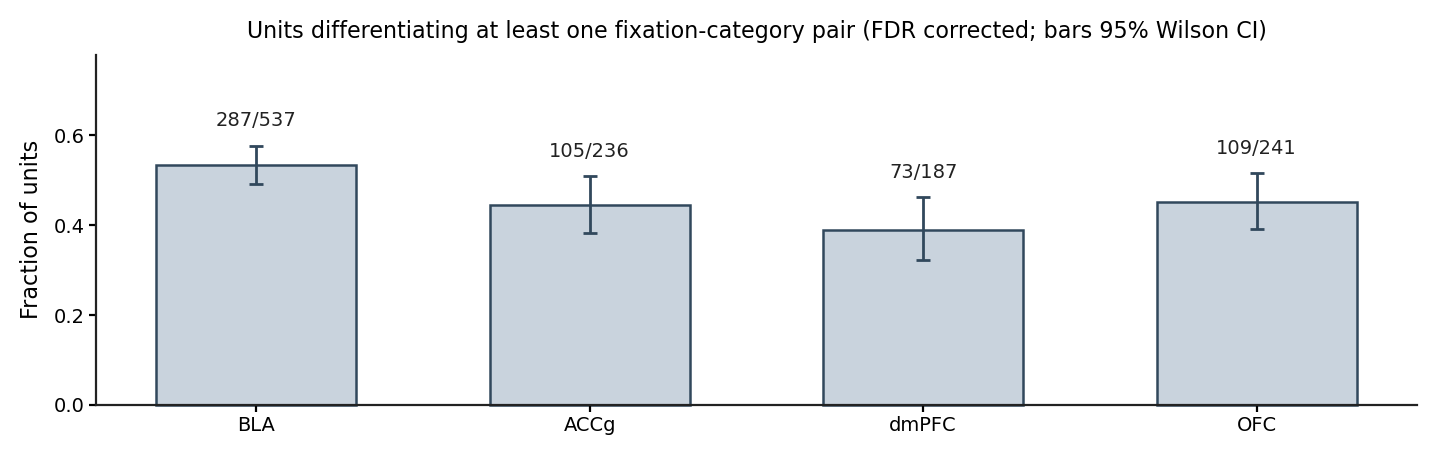

,region,region_label,n_units,n_selective,fraction,ci_low,ci_high,n_sessions
0,bla,BLA,537,287,0.534,0.492,0.576,35
1,accg,ACCg,236,105,0.445,0.383,0.509,19
2,dmpfc,dmPFC,187,73,0.390,0.323,0.462,17
3,ofc,OFC,241,109,0.452,0.391,0.515,14


In [4]:
fig, yield_table = figs.plot_unit_yield_panel(units)
FIGURE_MANIFEST["fig02_unit_yield"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig02_unit_yield"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(yield_table.round(3))

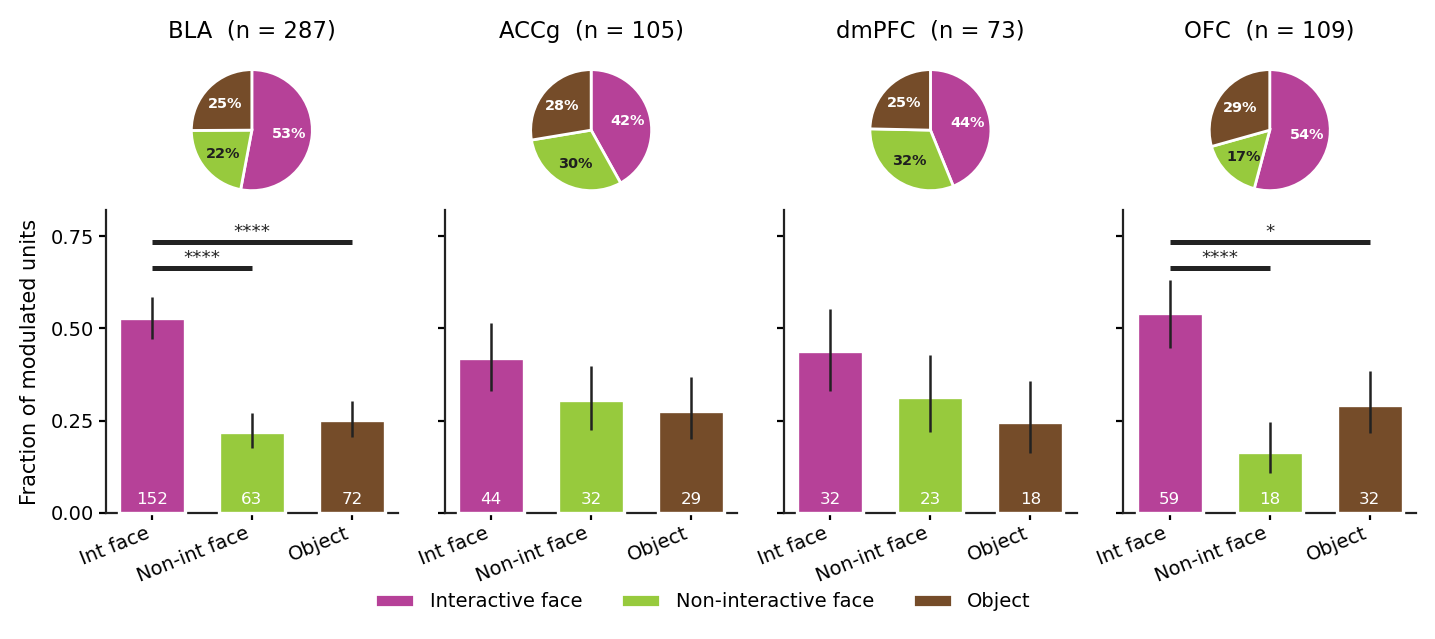

,region_label,condition,k,n,fraction,ci_low,ci_high
0,BLA,face_interactive,152,287,0.5296,0.4719,0.5866
1,BLA,face_non_interactive,63,287,0.2195,0.1755,0.2709
2,BLA,object,72,287,0.2509,0.2042,0.3041
3,ACCg,face_interactive,44,105,0.4190,0.3292,0.5146
4,ACCg,face_non_interactive,32,105,0.3048,0.2249,0.3984
5,ACCg,object,29,105,0.2762,0.1997,0.3685
6,dmPFC,face_interactive,32,73,0.4384,0.3305,0.5524
7,dmPFC,face_non_interactive,23,73,0.3151,0.2200,0.4286
8,dmPFC,object,18,73,0.2466,0.1620,0.3564
9,OFC,face_interactive,59,109,0.5413,0.4479,0.6318


,region_label,condition_a,condition_b,k_a,k_b,n_pair,p_value,p_adj,stars,significant
0,BLA,face_interactive,face_non_interactive,152,63,215,0.0000,0.0000,****,True
1,BLA,face_interactive,object,152,72,224,0.0000,0.0000,****,True
2,BLA,face_non_interactive,object,63,72,135,0.4913,0.5811,n.s.,False
3,ACCg,face_interactive,face_non_interactive,44,32,76,0.2067,0.3101,n.s.,False
4,ACCg,face_interactive,object,44,29,73,0.1006,0.1725,n.s.,False
5,ACCg,face_non_interactive,object,32,29,61,0.7982,0.7982,n.s.,False
6,dmPFC,face_interactive,face_non_interactive,32,23,55,0.2806,0.3741,n.s.,False
7,dmPFC,face_interactive,object,32,18,50,0.0649,0.1298,n.s.,False
8,dmPFC,face_non_interactive,object,23,18,41,0.5327,0.5811,n.s.,False
9,OFC,face_interactive,face_non_interactive,59,18,77,0.0000,0.0000,****,True


In [5]:
fig, preference_table, preference_contrasts = figs.plot_preferred_condition_panel(
    units.loc[units["is_selective"]]
)
FIGURE_MANIFEST["fig03_preferred_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig03_preferred_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    preference_table.loc[
        :, ["region_label", "condition", "k", "n", "fraction", "ci_low", "ci_high"]
    ].round(4)
)
display(
    preference_contrasts.loc[
        :, ["region_label", "condition_a", "condition_b", "k_a", "k_b", "n_pair",
            "p_value", "p_adj", "stars", "significant"]
    ].round(4)
)

## 4 · Different subpopulations differentiate different fixation pairs

Preference for interactive face is not the whole story: units also separate
non-interactive face from object, and many separate more than one pair. The UpSet
plot below partitions each region's selective units by exactly which pairs they
separate.

An UpSet rather than a Venn: three-set Venns cannot in general be drawn
area-proportionally — some combinations of the seven subset sizes admit no valid
circle geometry — and per-region area scaling would give each of the four panels a
different shape, defeating the comparison. Bars are the fraction of each region's
selective units so regions are comparable despite differing yields; unit counts are
printed on each bar.

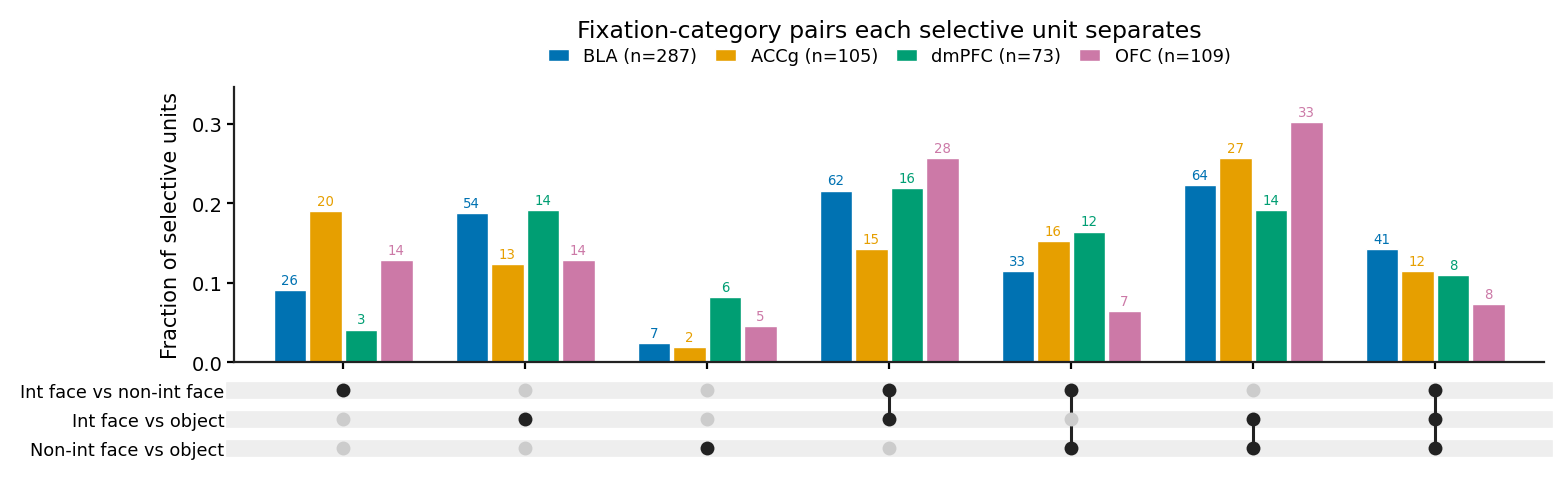

,region,region_label,100,010,001,110,101,011,111,n_selective,n_units
0,bla,BLA,26,54,7,62,33,64,41,287,537
1,accg,ACCg,20,13,2,15,16,27,12,105,236
2,dmpfc,dmPFC,3,14,6,16,12,14,8,73,187
3,ofc,OFC,14,14,5,28,7,33,8,109,241


In [6]:
pair_membership = figs.compute_pair_selectivity_membership(pair_selectivity)
fig, upset_counts = figs.plot_pair_selectivity_upset_panel(
    pair_membership,
    region_totals=units.groupby("region").size().to_dict(),
)
FIGURE_MANIFEST["fig04_pair_selectivity_upset"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig04_pair_selectivity_upset"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(upset_counts)

## 5 · Two metrics for the firing-rate profile

Selective units differ in *how* their rate changes, not only in which category they
prefer. Two quantities, both measured on the trace of the unit's preferred category,
capture the two things that vary:

- **Dominant-peak width** — full width at half maximum of the excess response (ms).
  How narrow or wide the dominant peak is.
- **Dominant-peak prominence** — $1 - P_2/P_1$, where $P_1$ is the dominant peak's
  topographic prominence and $P_2$ the largest prominence at least 250 ms away.
  **1** means a single clear peak; **0** means a second peak of equal prominence
  exists.

The two axes therefore read as *narrow versus wide* and *single-peak versus
multi-peak*, and the corner labels in §6 use exactly those words.

They replace the single composite score used previously. That composite,
$P_1/(1+\lambda P_2/P_1)$, correlates **0.99 with $P_1$ alone** — the discount term
spans too little range to matter — so it measured peak *height* while being
described as measuring isolation, and peak height is exactly the quantity trial
count corrupts. Halfwidth and isolation are near-independent (ρ ≈ −0.26) and both
are trial-count insensitive (ρ = +0.12 and −0.001).

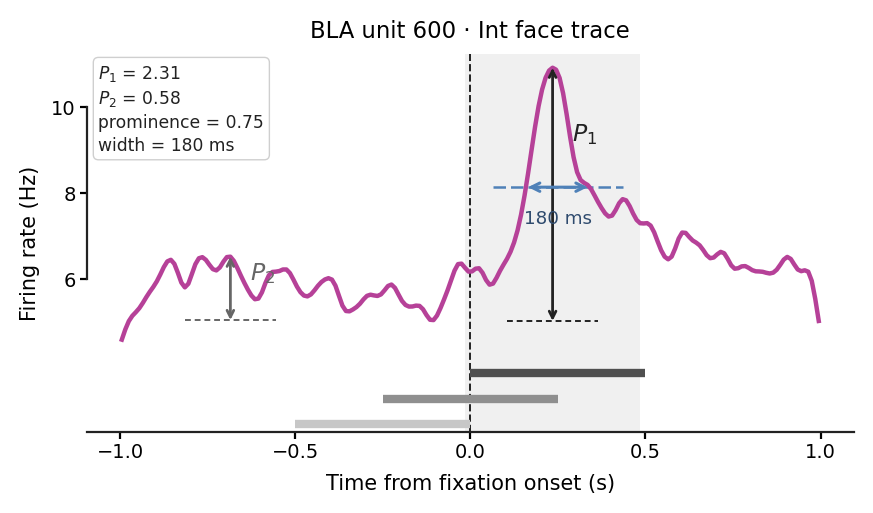

In [7]:
schematic_row = condition_traces.loc[
    (condition_traces["unit_uuid"] == "unit_uuid__600")
    & (condition_traces["condition"] == "face_interactive")
].iloc[0]
schematic_decomposition = decompose_dominant_peak_prominence(
    np.asarray(schematic_row["trace_hz"], dtype=float),
    np.asarray(schematic_row["bin_centers_s_rel"], dtype=float),
    peakiness_settings,
)
schematic_width = float(
    trace_shape.loc[trace_shape["uuid"] == "600", "response_duration_ms"].iloc[0]
)
fig = space.plot_isolation_schematic(
    schematic_decomposition, unit_label="BLA unit 600", duration_ms=schematic_width
)
FIGURE_MANIFEST["fig05_metric_schematic"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig05_metric_schematic"
)
display(Image(data=style.figure_to_png_bytes(fig)))

## 6 · Selective units occupy a continuum, not discrete types

Plotted against each other, the modulated population forms a **single unimodal
cloud** in every region. There is no narrow/wide or single/multi-peak dichotomy to
threshold — which is why these are treated as descriptive axes rather than a
taxonomy. Naming the corners is still useful, and each corner unit's own firing-rate
trace (its preferred category only) is inset beside its point so a coordinate in
this space can be read directly as a response shape.

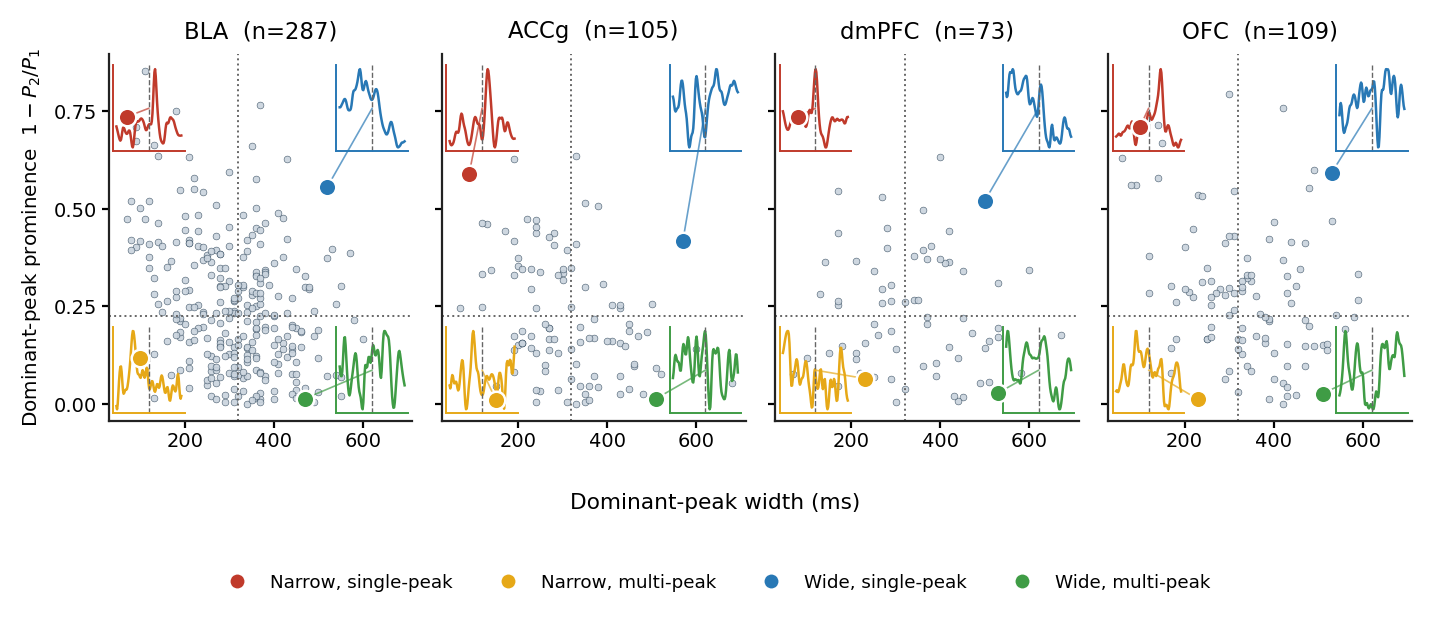

,region,n_units,width_median_ms,isolation_median,spearman_rho
0,BLA,287,310.0,0.232,-0.298
1,ACCg,105,300.0,0.175,-0.314
2,dmPFC,73,340.0,0.205,-0.090
3,OFC,109,340.0,0.274,-0.275


,region,corner,uuid,date,condition,response_duration_ms,peak_isolation,mean_fr_hz
0,bla,"Narrow, single-peak",2635,1102019,face_interactive,70.0,0.74,6.28
1,bla,"Narrow, multi-peak",2710,1142019,object,100.0,0.12,4.31
2,bla,"Wide, single-peak",2697,1132019,object,520.0,0.56,12.80
3,bla,"Wide, multi-peak",732,8312018,face_interactive,470.0,0.01,3.94
4,accg,"Narrow, single-peak",380,1172019,object,90.0,0.59,3.28
5,accg,"Narrow, multi-peak",390,1172019,face_interactive,150.0,0.01,4.49
6,accg,"Wide, single-peak",129,1172018,face_interactive,570.0,0.42,22.31
7,accg,"Wide, multi-peak",335,1132019,object,510.0,0.01,12.24
8,dmpfc,"Narrow, single-peak",1771,1092019,face_interactive,80.0,0.74,5.14
9,dmpfc,"Narrow, multi-peak",1741,1082019,face_interactive,230.0,0.07,8.97


In [8]:
corner_units = pd.concat(
    [space.select_corner_units(trace_shape, region=region) for region in style.REGION_ORDER],
    ignore_index=True,
)
fig, metric_space_summary = space.plot_metric_space_panel(
    trace_shape, corners=corner_units, condition_traces=condition_traces
)
FIGURE_MANIFEST["fig06_metric_space"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig06_metric_space"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(metric_space_summary.round(3))
display(
    corner_units.loc[
        :, ["region", "corner", "uuid", "date", "condition", "response_duration_ms",
            "peak_isolation", "mean_fr_hz"]
    ].round(2)
)

## 7 · Dominant-peak width by fixation category — supplementary

Within unit, is the response to one category held longer than to another? Violins
follow the project's behavioural convention (seaborn, quartile lines inside, kernel
truncated at the data range). Paired *t*-tests, FDR corrected across the whole
region × comparison family.

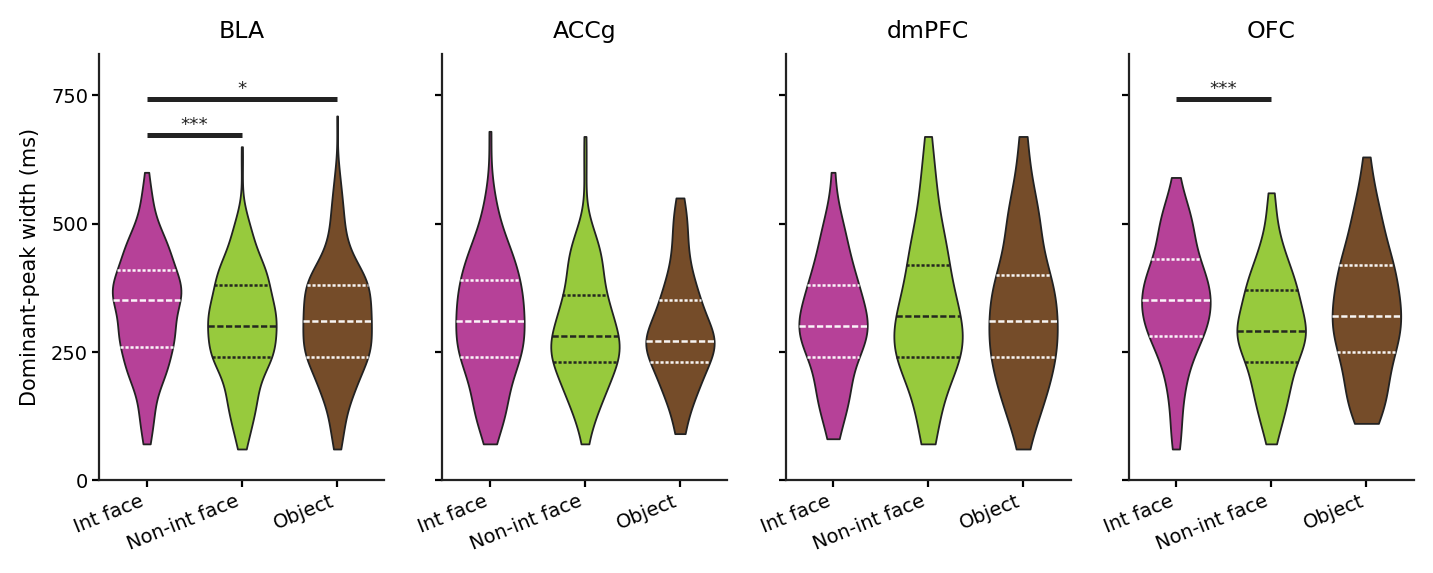

,region_label,condition_b,n_units,median_a,median_b,statistic,p_adj,stars
0,BLA,face_non_interactive,287,350.0,300.0,3.749,0.001,***
1,BLA,object,287,350.0,310.0,2.481,0.036,*
2,ACCg,face_non_interactive,105,310.0,280.0,1.075,0.380,n.s.
3,ACCg,object,105,310.0,270.0,1.472,0.288,n.s.
4,dmPFC,face_non_interactive,73,300.0,320.0,-0.884,0.380,n.s.
5,dmPFC,object,73,300.0,310.0,-0.918,0.380,n.s.
6,OFC,face_non_interactive,109,350.0,290.0,3.896,0.001,***
7,OFC,object,109,350.0,320.0,1.094,0.380,n.s.


In [9]:
fig, width_table = figs.plot_condition_metric_panel(
    trace_shape_all.loc[trace_shape_all["is_selective"]],
    metric="response_duration_ms",
    metric_label=space.WIDTH_LABEL,
)
FIGURE_MANIFEST["fig07_width_by_condition"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig07_width_by_condition"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    width_table.loc[
        :, ["region_label", "condition_b", "n_units", "median_a", "median_b",
            "statistic", "p_adj", "stars"]
    ].round(3)
)

### Methods note: why dominant-peak width and not the coefficient of variation

The obvious alternative — the CV of the mean firing-rate trace across time bins —
is **not usable for comparing fixation categories here**. Interactive-face fixations
are about five times more numerous than the others (median 846 trials per unit
versus 168 and 168). The number of time bins is identical in every condition, but
that does not protect the statistic: each bin of the mean trace is itself a trial
average, so writing `m(t) = s(t) + e(t)` gives

$$\operatorname{Var}_t[m] \approx \operatorname{Var}_t[s] + \mathbb{E}[\sigma^2]/N$$

and a condition observed with fewer trials inherits extra across-bin variance from
estimation noise alone. Equalising trial counts within unit and recomputing from 25
matched subsamples removes the apparent interactive-face advantage entirely. The
right panel shows the mechanism: subsampling interactive-face trials, holding
condition and neural signal fixed, inflates that condition's own CV by up to 2.4×.
Dominant-peak width is a width rather than an amplitude and is not affected.

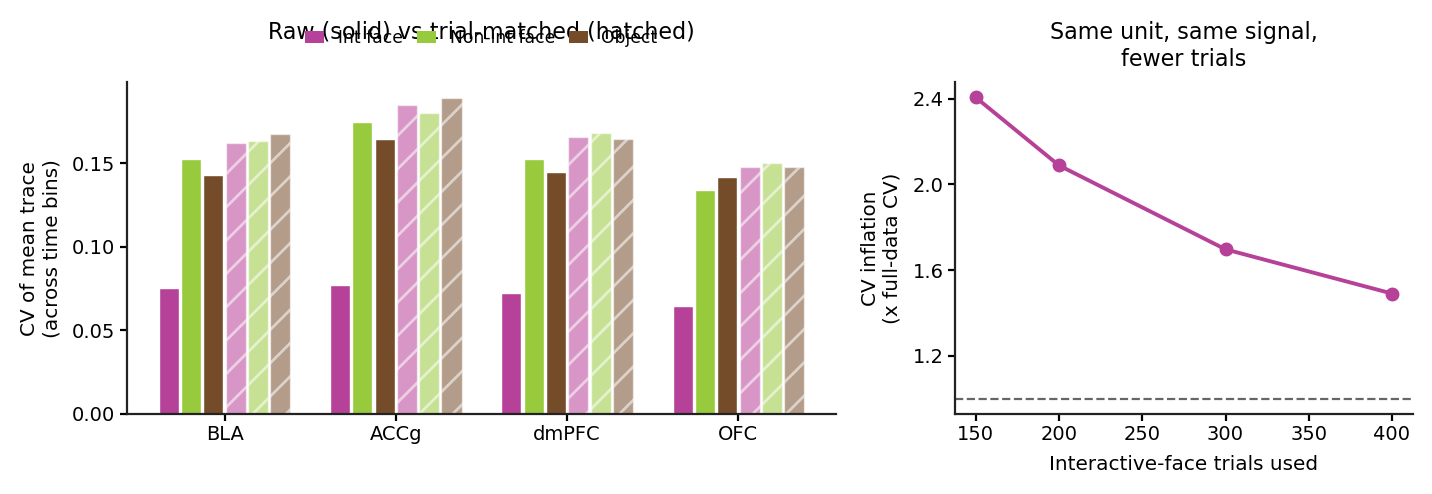

,region,variant,condition_b,n_units_paired,median_a,median_b,statistic,p_value_adjusted,significant_adjusted
0,ofc,cv_full,face_non_interactive,241,0.0646,0.1339,-18.3136,0.0000,True
1,ofc,cv_full,object,241,0.0646,0.1418,-16.7915,0.0000,True
3,ofc,cv_matched,face_non_interactive,241,0.1474,0.1502,-1.3319,0.2762,False
4,ofc,cv_matched,object,241,0.1474,0.1474,-2.5007,0.0314,True
6,bla,cv_full,face_non_interactive,537,0.0754,0.1522,-25.1123,0.0000,True
7,bla,cv_full,object,537,0.0754,0.1427,-20.4079,0.0000,True
9,bla,cv_matched,face_non_interactive,537,0.1618,0.1629,-1.7161,0.1735,False
10,bla,cv_matched,object,537,0.1618,0.1671,-2.6004,0.0314,True
12,accg,cv_full,face_non_interactive,236,0.0771,0.1746,-18.7120,0.0000,True
13,accg,cv_full,object,236,0.0771,0.1642,-17.0738,0.0000,True


In [10]:
fig = space.plot_cv_trial_matched_control(matched_cv, cv_inflation)
FIGURE_MANIFEST["fig08_cv_trial_matched_control"] = style.save_thesis_figure(
    fig, FIGURE_SETTINGS, "fig08_cv_trial_matched_control"
)
display(Image(data=style.figure_to_png_bytes(fig)))
display(
    matched_cv_stats.loc[
        matched_cv_stats["condition_a"] == "face_interactive",
        ["region", "variant", "condition_b", "n_units_paired", "median_a", "median_b",
         "statistic", "p_value_adjusted", "significant_adjusted"],
    ].round(4)
)

## 8 · Numbers and methods for the chapter text

Everything the prose needs, read back from the persisted tables so the written
chapter cannot drift from the figures.

In [11]:
chapter_text = text.build_chapter_text_summary(
    units=units,
    yield_table=yield_table,
    preference_table=preference_table,
    preference_contrasts=preference_contrasts,
    upset_counts=upset_counts,
    trace_shape=trace_shape_all,
    metric_space_summary=metric_space_summary,
    width_table=width_table,
    matched_cv_stats=matched_cv_stats,
    cv_inflation=cv_inflation,
    psth_cfg=psth_cfg,
)
(FIGURE_SETTINGS.output_dir / "chapter_text_numbers.md").write_text(chapter_text, encoding="utf-8")
display(Markdown(chapter_text))

# Chapter text — numbers and methods

*Generated from the persisted analysis tables; do not retype.*

## 1 · Recording yield

- **1201 single units** were isolated across **42 sessions**: **537** in BLA, **236** in ACCg, **187** in dmPFC, **241** in OFC.
- Sessions per region: 35 in BLA, 19 in ACCg, 17 in dmPFC, 14 in OFC. BLA was recorded simultaneously with one prefrontal region in every session, so the BLA total exceeds any single prefrontal total.

## 2 · Fixation-category selectivity

**How it was calculated.**

- Spike counts were binned at **10 ms** and smoothed with a **20 ms** Gaussian kernel before averaging within each analysis window.
- Firing rate was averaged per trial within three 500 ms windows: **pre-fix (-500 to +0 ms), peri-fix (-250 to +250 ms), post-fix (+0 to +500 ms)**, all relative to fixation onset.
- The three fixation categories are **interactive face**, **non-interactive face**, **object**, giving three pairwise contrasts.
- Each pair was compared in each window with a **two-sided Welch's *t*-test (unequal variances)** on the per-trial window-mean rates, requiring at least **2 trials per condition**.
- That gives **3 pairs × 3 windows = 9 tests per unit**. p-values were corrected **within unit** across all 9 tests using the **Benjamini–Hochberg FDR** procedure (`fdr_bh`), at **α = 0.05**.
- A unit was called **fixation-category-modulated (selective)** if *any* of its 9 corrected tests was significant.

**Result.**

- **574/1201** units were selective after correction (47.8%); 833/1201 were significant before correction.
- By region: **287/537 in BLA, 105/236 in ACCg, 73/187 in dmPFC, 109/241 in OFC**.
- Proportions with 95% Wilson score intervals: BLA 0.534 [0.492, 0.576]; ACCg 0.445 [0.383, 0.509]; dmPFC 0.390 [0.323, 0.462]; OFC 0.452 [0.391, 0.515].

## 3 · Which category pairs each unit separates

- Counts below are units assigned to exactly one of the seven non-empty intersection subsets of the three pairwise contrasts (the UpSet panel).
  - **BLA** (n = 287) — int vs non-int face only: 26, int face vs object only: 54, non-int face vs object only: 7, both interactive-face contrasts: 62, int vs non-int face + non-int face vs object: 33, int face vs object + non-int face vs object: 64, all three pairs: 41
  - **ACCg** (n = 105) — int vs non-int face only: 20, int face vs object only: 13, non-int face vs object only: 2, both interactive-face contrasts: 15, int vs non-int face + non-int face vs object: 16, int face vs object + non-int face vs object: 27, all three pairs: 12
  - **dmPFC** (n = 73) — int vs non-int face only: 3, int face vs object only: 14, non-int face vs object only: 6, both interactive-face contrasts: 16, int vs non-int face + non-int face vs object: 12, int face vs object + non-int face vs object: 14, all three pairs: 8
  - **OFC** (n = 109) — int vs non-int face only: 14, int face vs object only: 14, non-int face vs object only: 5, both interactive-face contrasts: 28, int vs non-int face + non-int face vs object: 7, int face vs object + non-int face vs object: 33, all three pairs: 8
- Units separating **more than one pair**: BLA 200/287 (70%), ACCg 70/105 (67%), dmPFC 50/73 (68%), OFC 76/109 (70%).

## 4 · Preferred fixation category

**How it was calculated.**

- For every selective unit, mean firing rate was computed for each category over the **-500 to +500 ms** window; the category with the highest mean was recorded as that unit's preferred category.
- Categories were compared **against each other**, not against a 1/3 reference. Each unit has exactly one preferred category, so the three counts form a single multinomial over a fixed n; the question of interest is whether more units prefer one category than another.
- Two categories were compared by restricting to the units preferring **either** of them and testing that split against 0.5 with a **two-sided exact binomial test** — the standard cell-versus-cell comparison within a multinomial.
- The **4 regions × 3 category pairs = 12 tests** were corrected together with **Benjamini–Hochberg FDR** at **α = 0.05**.
- Error bars are 95% **Wilson score** intervals on the proportion. Only significant contrasts are marked on the figure.

**Result — composition.**

  - **BLA** — interactive face 152/287 (0.530 [0.472, 0.587]); non-interactive face 63/287 (0.220 [0.176, 0.271]); object 72/287 (0.251 [0.204, 0.304])
  - **ACCg** — interactive face 44/105 (0.419 [0.329, 0.515]); non-interactive face 32/105 (0.305 [0.225, 0.398]); object 29/105 (0.276 [0.200, 0.368])
  - **dmPFC** — interactive face 32/73 (0.438 [0.330, 0.552]); non-interactive face 23/73 (0.315 [0.220, 0.429]); object 18/73 (0.247 [0.162, 0.356])
  - **OFC** — interactive face 59/109 (0.541 [0.448, 0.632]); non-interactive face 18/109 (0.165 [0.107, 0.246]); object 32/109 (0.294 [0.216, 0.385])

**Result — comparisons between categories.**

  - **BLA** interactive face (152) vs non-interactive face (63) — 152/215 of the units preferring either, p_adj = 1.37e-08 ****
  - **BLA** interactive face (152) vs object (72) — 152/224 of the units preferring either, p_adj = 5.77e-07 ****
  - **BLA** non-interactive face (63) vs object (72) — 63/135 of the units preferring either, p_adj = 0.581 n.s.
  - **ACCg** interactive face (44) vs non-interactive face (32) — 44/76 of the units preferring either, p_adj = 0.31 n.s.
  - **ACCg** interactive face (44) vs object (29) — 44/73 of the units preferring either, p_adj = 0.173 n.s.
  - **ACCg** non-interactive face (32) vs object (29) — 32/61 of the units preferring either, p_adj = 0.798 n.s.
  - **dmPFC** interactive face (32) vs non-interactive face (23) — 32/55 of the units preferring either, p_adj = 0.374 n.s.
  - **dmPFC** interactive face (32) vs object (18) — 32/50 of the units preferring either, p_adj = 0.13 n.s.
  - **dmPFC** non-interactive face (23) vs object (18) — 23/41 of the units preferring either, p_adj = 0.581 n.s.
  - **OFC** interactive face (59) vs non-interactive face (18) — 59/77 of the units preferring either, p_adj = 1.22e-05 ****
  - **OFC** interactive face (59) vs object (32) — 59/91 of the units preferring either, p_adj = 0.0183 *
  - **OFC** non-interactive face (18) vs object (32) — 18/50 of the units preferring either, p_adj = 0.13 n.s.

## 5 · Firing-rate profile metrics

Both metrics are computed on the trial-averaged firing-rate trace of each unit's **preferred** fixation category, over **-500 to +500 ms** relative to fixation onset. Baseline is the **10th percentile** of that windowed trace, and the *excess* response is the trace minus baseline, clipped at zero.

**Dominant-peak width (ms).**

- Full width at half maximum of the excess response: the total time the excess rate is at or above half its peak value, in ms.
- Being a width rather than an amplitude, it is insensitive to how many trials the average was built from (Spearman ρ with log trial count = **+0.12**).

**Dominant-peak prominence (1 − P₂/P₁).**

- The trace is first divided by **√(mean firing rate)** (`sqrt_mean`), a variance-stabilising step that makes prominences comparable between low- and high-rate units.
- All local peaks at least **30 ms** apart are detected (`scipy.signal.find_peaks`) and each is assigned its **topographic prominence** — the height it rises above the highest saddle separating it from any taller peak.
- **P₁** is the largest prominence. **P₂** is the largest prominence at least **250 ms** away from P₁, i.e. the strongest genuinely separate rival.
- The metric is **1 − P₂/P₁**, bounded on [0, 1]: **1** means a single clear peak, **0** means a second peak of equal prominence exists.
- Spearman ρ with log trial count = **−0.001**, i.e. no trial-count sensitivity.

**Distributions (selective units, preferred-category trace).**

  - **BLA** (n = 287) — width median 310 ms, prominence median 0.23, width × prominence Spearman ρ = -0.30
  - **ACCg** (n = 105) — width median 300 ms, prominence median 0.18, width × prominence Spearman ρ = -0.31
  - **dmPFC** (n = 73) — width median 340 ms, prominence median 0.20, width × prominence Spearman ρ = -0.09
  - **OFC** (n = 109) — width median 340 ms, prominence median 0.27, width × prominence Spearman ρ = -0.28
  - Pooled across regions, the two metrics are near-independent (Spearman ρ = **-0.22**), and both distributions are unimodal — there is no discrete grouping of units in this space.

## 6 · Dominant-peak width by fixation category (supplementary)

**How it was calculated.**

- Width was recomputed on *each* category's trace for every selective unit, so all three values come from the same unit.
- Interactive face was compared against each other category with a **two-sided paired t-test** across units within region.
- The **4 regions × 2 comparisons = 8 tests** were corrected together with **Benjamini–Hochberg FDR** at **α = 0.05**.

**Result.**

  - **BLA** int face 350 ms vs non-interactive face 300 ms — t(286) = 3.75, p_adj = 0.00086 ***
  - **BLA** int face 350 ms vs object 310 ms — t(286) = 2.48, p_adj = 0.0365 *
  - **ACCg** int face 310 ms vs non-interactive face 280 ms — t(104) = 1.08, p_adj = 0.38 n.s.
  - **ACCg** int face 310 ms vs object 270 ms — t(104) = 1.47, p_adj = 0.288 n.s.
  - **dmPFC** int face 300 ms vs non-interactive face 320 ms — t(72) = -0.88, p_adj = 0.38 n.s.
  - **dmPFC** int face 300 ms vs object 310 ms — t(72) = -0.92, p_adj = 0.38 n.s.
  - **OFC** int face 350 ms vs non-interactive face 290 ms — t(108) = 3.90, p_adj = 0.00086 ***
  - **OFC** int face 350 ms vs object 320 ms — t(108) = 1.09, p_adj = 0.38 n.s.

## 7 · Why the coefficient of variation is not used (methods note)

- Trial counts are strongly unequal across categories (median per unit: interactive face 846, non-interactive face 168, object 168).
- The CV of the mean trace **across time bins** appears far lower for interactive face, but each bin of that mean is itself a trial average, so Var_t[m] ≈ Var_t[s] + E[σ²]/N: a category seen with fewer trials inherits extra across-bin variance from estimation noise alone. The equal number of time bins does not protect the statistic.
- Subsampling interactive-face trials while holding condition and neural signal fixed inflates that category's own CV by **2.41×** at N = 150, **2.09×** at N = 200, **1.70×** at N = 300, **1.49×** at N = 400.
- After equalising trial counts within unit (25 matched subsamples per unit, median matched N = 140), the interactive-face advantage disappears: 5/8 comparisons remain significant and all median differences are ≤ 0.005 CV units.
- **Dominant-peak width is reported instead**, being a width rather than an amplitude and therefore not subject to this confound.


## 9 · Persist tables and figure manifest

In [12]:
exports = {
    "unit_yield_by_region.csv": yield_table,
    "preferred_condition_by_region.csv": preference_table,
    "preferred_condition_contrasts.csv": preference_contrasts,
    "pair_selectivity_upset_counts.csv": upset_counts,
    "metric_space_summary.csv": metric_space_summary,
    "metric_space_corner_units.csv": corner_units.loc[
        :, ["region", "corner", "uuid", "date", "condition", "response_duration_ms",
            "peak_isolation"]
    ],
    "width_by_condition.csv": width_table,
    "cv_trial_matched_stats.csv": matched_cv_stats,
}
for filename, frame in exports.items():
    frame.to_csv(FIGURE_SETTINGS.output_dir / filename, index=False)
    print(f"wrote {filename:40s} ({len(frame)} rows)")

print()
for stem in FIGURE_MANIFEST:
    print(stem)

wrote unit_yield_by_region.csv                 (4 rows)
wrote preferred_condition_by_region.csv        (12 rows)
wrote preferred_condition_contrasts.csv        (12 rows)
wrote pair_selectivity_upset_counts.csv        (4 rows)
wrote metric_space_summary.csv                 (4 rows)
wrote metric_space_corner_units.csv            (16 rows)
wrote width_by_condition.csv                   (8 rows)
wrote cv_trial_matched_stats.csv               (24 rows)

fig01_interactive_face_examples
fig02_unit_yield
fig03_preferred_condition
fig04_pair_selectivity_upset
fig05_metric_schematic
fig06_metric_space
fig07_width_by_condition
fig08_cv_trial_matched_control


## Summary

Here are neurons selective for interactive face fixations (§2), and interactive face
is the preferred category across the modulated population (§3) — but there are other
kinds of selectivity too (§4). Across that population, selective neurons express
their selectivity through a range of firing-rate profiles, which two metrics
elucidate (§5–§6): **dominant-peak width** and **dominant-peak prominence**. Those axes are
independent and continuous, so the corner labels are descriptive convenience rather
than cell types.

Dominant-peak width also differs modestly by fixation category (§7), interactive-face
responses being held longer in BLA and OFC. The coefficient of variation appears to
show a far larger effect but is an artefact of unequal trial counts and is not used.

The appendix (`single_unit_trace_metrics_appendix.ipynb`) reports the wider set of
trace metrics, which are redundant, and how each relates to these two.